# Drug Demand Forecasting with Time-Series and Machine-Learning Models

This notebook demonstrates a drug-level demand forecasting workflow using synthetic monthly data.

The project compares:

- Seasonal Naive forecasting
- Exponential Smoothing
- SARIMA
- Random Forest regression with lag features
- Gradient Boosting regression with lag features

For every drug, the models are evaluated on the most recent six months.  
The model with the lowest Mean Absolute Error is selected and used to forecast the next three months.


In [2]:
# Cell 1: Import required libraries
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings("ignore")

In [3]:
# Cell 2: Load the dataset
DATA_PATH = Path("drug_forecasting_data.csv")
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (720, 6)


,drug,date,demand,supply,inventory,shortage
0,Drug_001,2022-01-01,304,289,3967.0,0
1,Drug_001,2022-02-01,414,438,3991.0,0
2,Drug_001,2022-03-01,445,445,3991.0,0
3,Drug_001,2022-04-01,493,581,4079.0,0
4,Drug_001,2022-05-01,451,549,4177.0,0


In [4]:
# Cell 3: Validate and prepare monthly time-series data
required_columns = [
    "drug",
    "date",
    "demand",
    "supply",
    "inventory",
    "shortage",
]

missing_columns = [
    column for column in required_columns
    if column not in df.columns
]

if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

df["date"] = pd.to_datetime(df["date"])

numeric_columns = ["demand", "supply", "inventory", "shortage"]

for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

df = (
    df.sort_values(["drug", "date"])
      .drop_duplicates(["drug", "date"])
      .reset_index(drop=True)
)

df[numeric_columns] = df[numeric_columns].fillna(
    df[numeric_columns].median(numeric_only=True)
)

print("Date range:", df["date"].min().date(), "to", df["date"].max().date())
print("Number of drugs:", df["drug"].nunique())
print("Rows per drug:")
display(df.groupby("drug").size().describe())

Date range: 2022-01-01 to 2025-12-01
Number of drugs: 15
Rows per drug:


count    15.0
mean     48.0
std       0.0
min      48.0
25%      48.0
50%      48.0
75%      48.0
max      48.0
dtype: float64

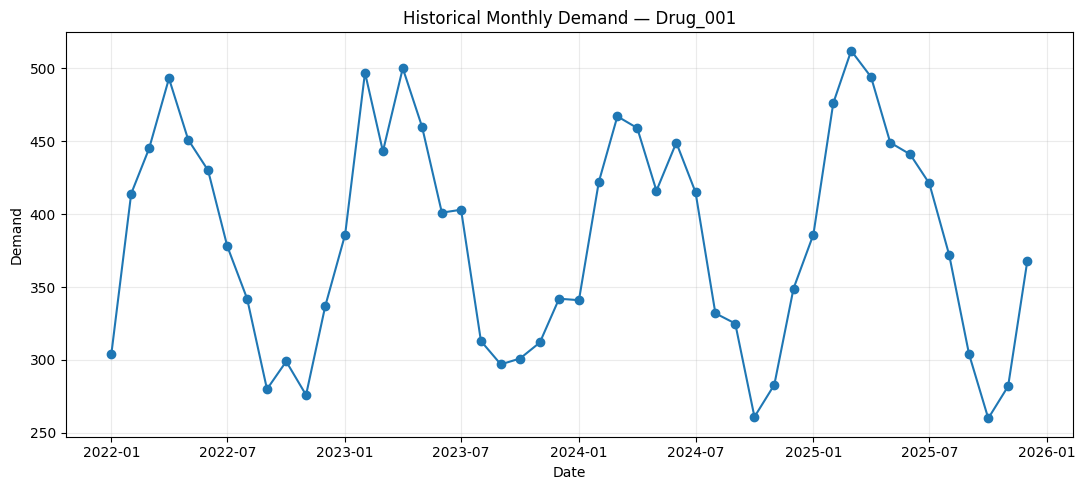

In [5]:
# Cell 4: Visualize the historical demand of one example drug
example_drug = df["drug"].iloc[0]

example_history = (
    df[df["drug"] == example_drug]
    .sort_values("date")
)

plt.figure(figsize=(11, 5))
plt.plot(
    example_history["date"],
    example_history["demand"],
    marker="o",
)
plt.title(f"Historical Monthly Demand — {example_drug}")
plt.xlabel("Date")
plt.ylabel("Demand")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## Forecasting approach

For each drug:

1. The final six months are kept as a test period.
2. Each model is trained using only earlier observations.
3. Predictions are compared with actual test-period demand.
4. MAE, RMSE, and R² are calculated.
5. The model with the lowest MAE is selected.
6. The selected model is retrained using the complete history.
7. The next three months are forecast.

The time-based split prevents future observations from leaking into model training.


In [6]:
# Cell 5: Helper function for lag-based machine-learning features
def create_lag_features(series):
    frame = pd.DataFrame({"demand": series.values}, index=series.index)

    frame["month"] = frame.index.month
    frame["year"] = frame.index.year

    frame["lag_1"] = frame["demand"].shift(1)
    frame["lag_2"] = frame["demand"].shift(2)
    frame["lag_3"] = frame["demand"].shift(3)
    frame["lag_6"] = frame["demand"].shift(6)
    frame["lag_12"] = frame["demand"].shift(12)

    frame["rolling_3"] = (
        frame["demand"].shift(1).rolling(3).mean()
    )
    frame["rolling_6"] = (
        frame["demand"].shift(1).rolling(6).mean()
    )

    return frame.dropna()


def recursive_ml_forecast(model, history, steps):
    history_values = list(history.astype(float))
    forecast_dates = pd.date_range(
        history.index.max() + pd.DateOffset(months=1),
        periods=steps,
        freq="MS",
    )

    predictions = []

    for forecast_date in forecast_dates:
        feature_row = pd.DataFrame([{
            "month": forecast_date.month,
            "year": forecast_date.year,
            "lag_1": history_values[-1],
            "lag_2": history_values[-2],
            "lag_3": history_values[-3],
            "lag_6": history_values[-6],
            "lag_12": history_values[-12],
            "rolling_3": np.mean(history_values[-3:]),
            "rolling_6": np.mean(history_values[-6:]),
        }])

        prediction = max(0, float(model.predict(feature_row)[0]))
        predictions.append(prediction)
        history_values.append(prediction)

    return pd.Series(predictions, index=forecast_dates)

In [7]:
# Cell 6: Forecast one drug with all candidate models
def evaluate_models_for_drug(drug_data, test_months=6):
    series = (
        drug_data.set_index("date")["demand"]
        .sort_index()
        .asfreq("MS")
        .interpolate()
    )

    if len(series) < 30:
        return None, None

    train = series.iloc[:-test_months]
    test = series.iloc[-test_months:]

    predictions = {}

    # 1. Seasonal Naive
    if len(train) >= 12:
        seasonal_values = train.iloc[-12:].values
        predictions["Seasonal Naive"] = pd.Series(
            [
                seasonal_values[index % 12]
                for index in range(test_months)
            ],
            index=test.index,
        )

    # 2. Exponential Smoothing
    try:
        ets_model = ExponentialSmoothing(
            train,
            trend="add",
            seasonal="add",
            seasonal_periods=12,
            initialization_method="estimated",
        ).fit(optimized=True)

        predictions["Exponential Smoothing"] = ets_model.forecast(
            test_months
        ).clip(lower=0)
    except Exception:
        pass

    # 3. SARIMA
    try:
        sarima_model = SARIMAX(
            train,
            order=(1, 1, 1),
            seasonal_order=(1, 1, 0, 12),
            enforce_stationarity=False,
            enforce_invertibility=False,
        ).fit(disp=False)

        predictions["SARIMA"] = sarima_model.forecast(
            test_months
        ).clip(lower=0)
    except Exception:
        pass

    # Lag-based ML dataset
    lag_data = create_lag_features(series)

    train_ml = lag_data[lag_data.index < test.index.min()]
    test_ml = lag_data[lag_data.index >= test.index.min()]

    ml_features = [
        "month",
        "year",
        "lag_1",
        "lag_2",
        "lag_3",
        "lag_6",
        "lag_12",
        "rolling_3",
        "rolling_6",
    ]

    if len(train_ml) > 10 and len(test_ml) == test_months:
        X_train = train_ml[ml_features]
        y_train = train_ml["demand"]

        # 4. Random Forest
        random_forest = RandomForestRegressor(
            n_estimators=200,
            max_depth=10,
            random_state=42,
            n_jobs=-1,
        )
        random_forest.fit(X_train, y_train)

        predictions["Random Forest"] = recursive_ml_forecast(
            random_forest,
            train,
            test_months,
        )

        # 5. Gradient Boosting
        gradient_boosting = GradientBoostingRegressor(
            n_estimators=150,
            learning_rate=0.05,
            max_depth=3,
            random_state=42,
        )
        gradient_boosting.fit(X_train, y_train)

        predictions["Gradient Boosting"] = recursive_ml_forecast(
            gradient_boosting,
            train,
            test_months,
        )

    evaluation_rows = []

    for model_name, forecast in predictions.items():
        forecast = forecast.reindex(test.index)

        mae = mean_absolute_error(test, forecast)
        rmse = np.sqrt(mean_squared_error(test, forecast))
        r2 = r2_score(test, forecast)

        evaluation_rows.append({
            "Model": model_name,
            "MAE": mae,
            "RMSE": rmse,
            "R2": r2,
        })

    evaluation = (
        pd.DataFrame(evaluation_rows)
        .sort_values("MAE")
        .reset_index(drop=True)
    )

    return evaluation, predictions

In [8]:
# Cell 7: Test the models for one example drug
example_data = df[df["drug"] == example_drug].copy()

example_evaluation, example_predictions = evaluate_models_for_drug(
    example_data,
    test_months=6,
)

display(example_evaluation.round(3))

,Model,MAE,RMSE,R2
0,Seasonal Naive,14.667,20.166,0.873
1,Gradient Boosting,17.523,22.100,0.848
2,Exponential Smoothing,20.444,23.798,0.823
3,SARIMA,23.954,27.845,0.758
4,Random Forest,25.253,29.783,0.723


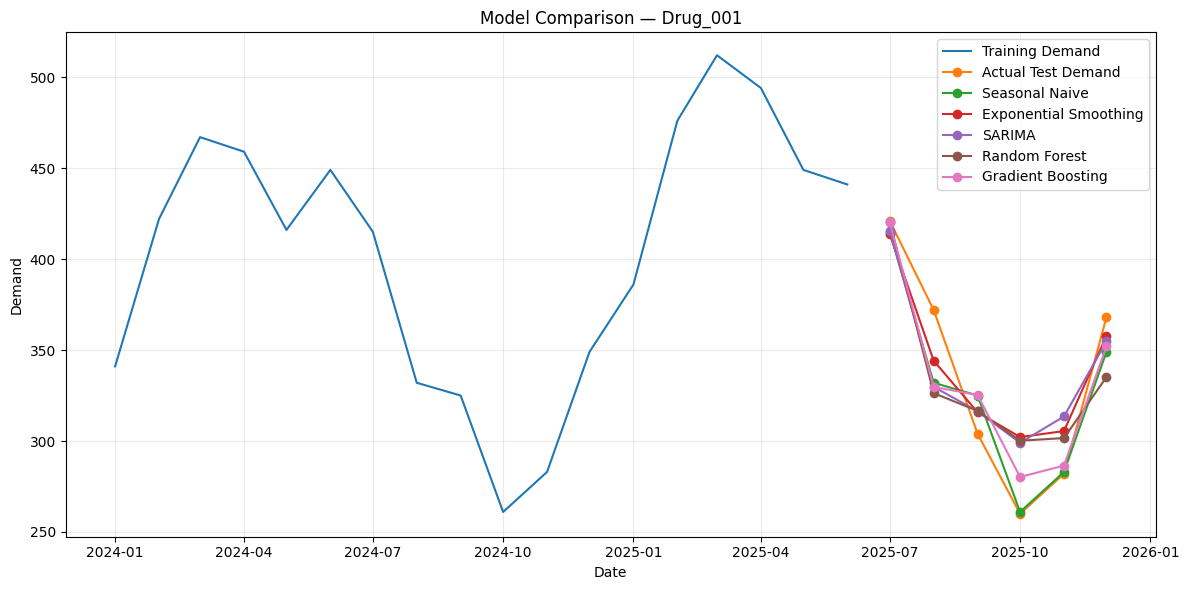

In [9]:
# Cell 8: Visualize test-period forecasts for the example drug
example_series = (
    example_data.set_index("date")["demand"]
    .sort_index()
    .asfreq("MS")
    .interpolate()
)

example_test = example_series.iloc[-6:]
example_train = example_series.iloc[:-6]

plt.figure(figsize=(12, 6))
plt.plot(
    example_train.tail(18).index,
    example_train.tail(18).values,
    label="Training Demand",
)
plt.plot(
    example_test.index,
    example_test.values,
    marker="o",
    label="Actual Test Demand",
)

for model_name, forecast in example_predictions.items():
    plt.plot(
        forecast.index,
        forecast.values,
        marker="o",
        label=model_name,
    )

plt.title(f"Model Comparison — {example_drug}")
plt.xlabel("Date")
plt.ylabel("Demand")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [10]:
# Cell 9: Evaluate all models for every drug
all_evaluations = []

for drug, drug_data in df.groupby("drug"):
    evaluation, _ = evaluate_models_for_drug(
        drug_data,
        test_months=6,
    )

    if evaluation is None or evaluation.empty:
        continue

    evaluation.insert(0, "drug", drug)
    all_evaluations.append(evaluation)

model_evaluation = pd.concat(
    all_evaluations,
    ignore_index=True,
)

display(model_evaluation.head(15).round(3))

,drug,Model,MAE,RMSE,R2
0,Drug_001,Seasonal Naive,14.667,20.166,0.873
1,Drug_001,Gradient Boosting,17.523,22.100,0.848
2,Drug_001,Exponential Smoothing,20.444,23.798,0.823
3,Drug_001,SARIMA,23.954,27.845,0.758
4,Drug_001,Random Forest,25.253,29.783,0.723
5,Drug_002,Exponential Smoothing,82.947,101.050,0.213
6,Drug_002,SARIMA,84.309,104.652,0.155
7,Drug_002,Gradient Boosting,95.827,115.256,-0.024
8,Drug_002,Random Forest,96.852,122.507,-0.157
9,Drug_002,Seasonal Naive,115.000,128.701,-0.277


In [11]:
# Cell 10: Select the best model for each drug
best_models = (
    model_evaluation
    .sort_values(["drug", "MAE"])
    .groupby("drug", as_index=False)
    .first()
    .rename(columns={"Model": "Best_Model"})
)

print("Best-model distribution:")
display(
    best_models["Best_Model"]
    .value_counts()
    .rename("Number_of_Drugs")
    .to_frame()
)

display(best_models.head().round(3))

Best-model distribution:


,Number_of_Drugs
Best_Model,
Seasonal Naive,4
Exponential Smoothing,4
Random Forest,3
Gradient Boosting,2
SARIMA,2


,drug,Best_Model,MAE,RMSE,R2
0,Drug_001,Seasonal Naive,14.667,20.166,0.873
1,Drug_002,Exponential Smoothing,82.947,101.050,0.213
2,Drug_003,Gradient Boosting,87.011,111.183,-1.102
3,Drug_004,Seasonal Naive,50.500,58.445,0.853
4,Drug_005,Random Forest,67.054,84.034,-1.745


In [12]:
# Cell 11: Function to refit the selected model and forecast three months
def forecast_with_selected_model(series, model_name, steps=3):
    series = series.asfreq("MS").interpolate()

    future_dates = pd.date_range(
        series.index.max() + pd.DateOffset(months=1),
        periods=steps,
        freq="MS",
    )

    if model_name == "Seasonal Naive":
        seasonal_values = series.iloc[-12:].values
        values = [
            seasonal_values[index % 12]
            for index in range(steps)
        ]
        return pd.Series(values, index=future_dates)

    if model_name == "Exponential Smoothing":
        model = ExponentialSmoothing(
            series,
            trend="add",
            seasonal="add",
            seasonal_periods=12,
            initialization_method="estimated",
        ).fit(optimized=True)

        return model.forecast(steps).clip(lower=0)

    if model_name == "SARIMA":
        model = SARIMAX(
            series,
            order=(1, 1, 1),
            seasonal_order=(1, 1, 0, 12),
            enforce_stationarity=False,
            enforce_invertibility=False,
        ).fit(disp=False)

        return model.forecast(steps).clip(lower=0)

    lag_data = create_lag_features(series)

    feature_columns = [
        "month",
        "year",
        "lag_1",
        "lag_2",
        "lag_3",
        "lag_6",
        "lag_12",
        "rolling_3",
        "rolling_6",
    ]

    X = lag_data[feature_columns]
    y = lag_data["demand"]

    if model_name == "Random Forest":
        model = RandomForestRegressor(
            n_estimators=200,
            max_depth=10,
            random_state=42,
            n_jobs=-1,
        )
    elif model_name == "Gradient Boosting":
        model = GradientBoostingRegressor(
            n_estimators=150,
            learning_rate=0.05,
            max_depth=3,
            random_state=42,
        )
    else:
        raise ValueError(f"Unsupported model: {model_name}")

    model.fit(X, y)

    return recursive_ml_forecast(
        model,
        series,
        steps,
    )

In [13]:
# Cell 12: Generate three-month forecasts for all drugs
forecast_rows = []

for _, best_row in best_models.iterrows():
    drug = best_row["drug"]
    selected_model = best_row["Best_Model"]

    series = (
        df[df["drug"] == drug]
        .set_index("date")["demand"]
        .sort_index()
    )

    forecast = forecast_with_selected_model(
        series,
        selected_model,
        steps=3,
    )

    for forecast_date, predicted_demand in forecast.items():
        forecast_rows.append({
            "drug": drug,
            "forecast_date": forecast_date,
            "predicted_demand": round(
                max(0, float(predicted_demand)),
                2,
            ),
            "selected_model": selected_model,
        })

forecast_results = pd.DataFrame(forecast_rows)

display(forecast_results.head(15))

,drug,forecast_date,predicted_demand,selected_model
0,Drug_001,2026-01-01,386.00,Seasonal Naive
1,Drug_001,2026-02-01,476.00,Seasonal Naive
2,Drug_001,2026-03-01,512.00,Seasonal Naive
3,Drug_002,2026-01-01,1255.07,Exponential Smoothing
4,Drug_002,2026-02-01,1361.82,Exponential Smoothing
5,Drug_002,2026-03-01,1528.81,Exponential Smoothing
6,Drug_003,2026-01-01,1679.77,Gradient Boosting
7,Drug_003,2026-02-01,1622.52,Gradient Boosting
8,Drug_003,2026-03-01,1480.98,Gradient Boosting
9,Drug_004,2026-01-01,1189.00,Seasonal Naive


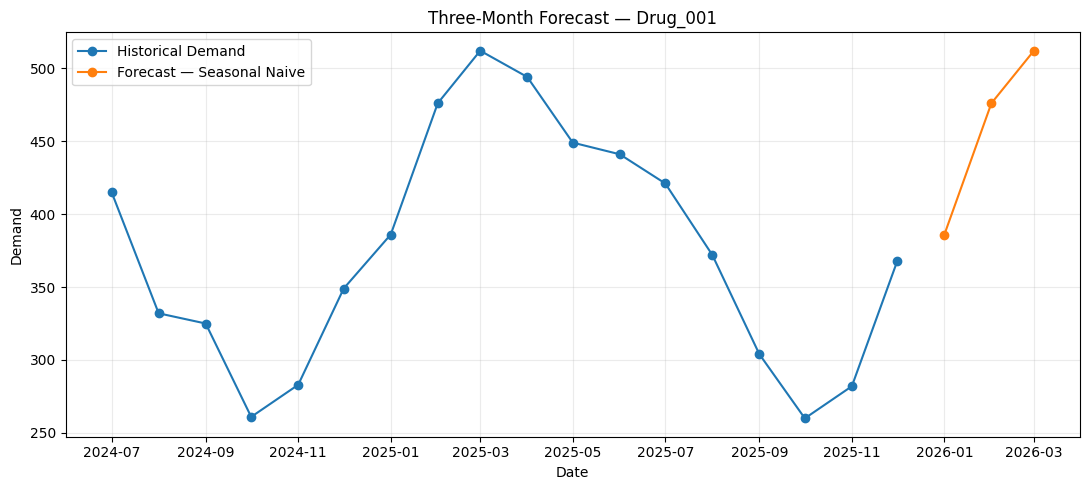

In [14]:
# Cell 13: Visualize the selected forecast for one drug
selected_example_model = (
    best_models.loc[
        best_models["drug"] == example_drug,
        "Best_Model",
    ].iloc[0]
)

example_forecast = forecast_results[
    forecast_results["drug"] == example_drug
]

example_history = (
    df[df["drug"] == example_drug]
    .sort_values("date")
    .tail(18)
)

plt.figure(figsize=(11, 5))
plt.plot(
    example_history["date"],
    example_history["demand"],
    marker="o",
    label="Historical Demand",
)
plt.plot(
    example_forecast["forecast_date"],
    example_forecast["predicted_demand"],
    marker="o",
    label=f"Forecast — {selected_example_model}",
)
plt.title(f"Three-Month Forecast — {example_drug}")
plt.xlabel("Date")
plt.ylabel("Demand")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## Interpretation

- **Seasonal Naive** provides a simple benchmark based on the same month of the previous year.
- **Exponential Smoothing** captures level, trend, and seasonality.
- **SARIMA** models autoregressive and seasonal patterns.
- **Random Forest** and **Gradient Boosting** use lag and rolling-demand features to capture non-linear relationships.
- The best model may differ from one drug to another because each drug can have a different historical demand pattern.

For shortage planning, forecast accuracy should be monitored regularly as new monthly data becomes available.
